# Retrieval-Augmented Generation(RAG) from Scratch

In this notebook, we will build a Retrieval-Augmented Generation(RAG) pipeline from scratch without using any popular libraries such as Langchain or Llamaindex.

RAG is a technique that retrieves related documents to the user's question, combines them with LLM-base prompt, and sends them to LLMs like GPT to produce more factually accurate generation.

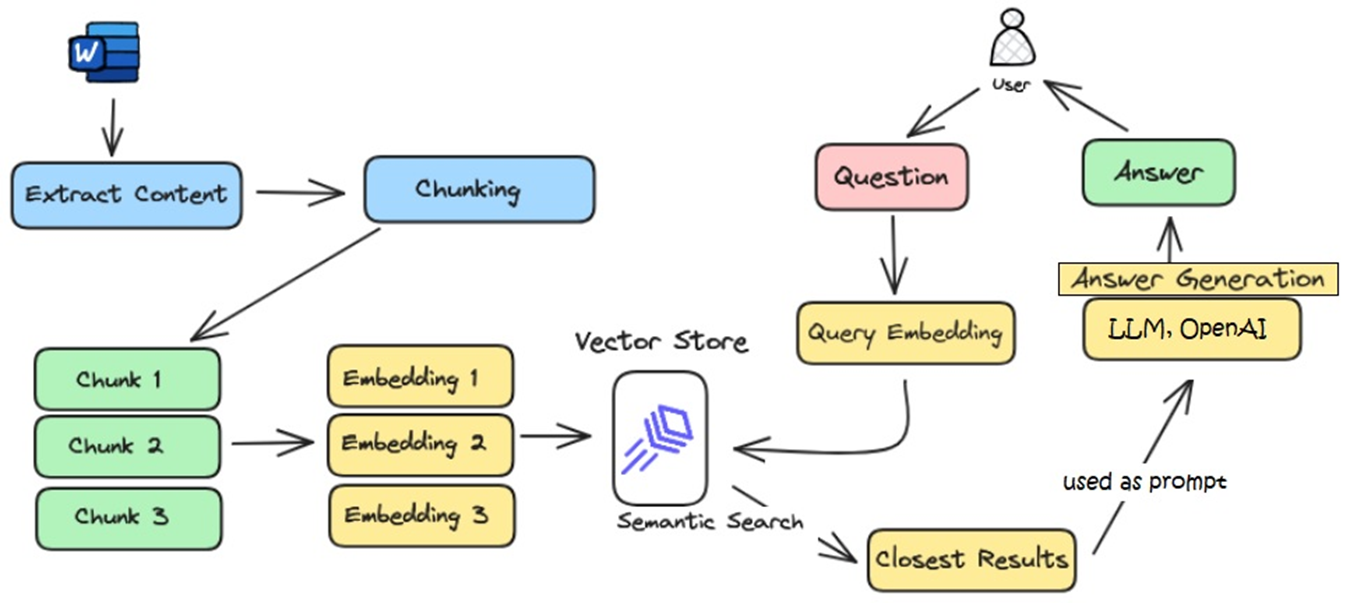![image.png]

Lets Split RAG Pipeline into 5 parts:

1. Data loading
2. Chunking and Embedding
3. Vector Store
4. Retrieval & Prompt preparation
5. Answer Generation

## Install Dependencies

In [1]:
# Install
!pip install transformers scikit-learn docx2txt datasets nltk lancedb -q

### Set OPENAI API KEY as env variable if not done already

In [2]:
# Set OPENAI_API_KEY
import os
from dotenv import load_dotenv

# Load environment variables from the .env file in your directory
load_dotenv()

# Retrieve the API key from the environment
api_key = os.getenv("OPENAI_API_KEY")

# Verify if the key was loaded successfully
if api_key:
    print(f"✓ API Key loaded successfully. Starts with: {api_key[:7]}...")
else:
    print("✗ API Key not found. Please check your .env file.")

✓ API Key loaded successfully. Starts with: sk-proj...


## Data Loading

In [3]:
# Load.txt is a small text file describing contents of lease agreements

# !wget link
with open("lease.txt", "r") as file:
    text_data = file.read()

## Data Chunking and Embedding
We will create some 11-12 chunks of text and create embedding vectors for each chunk.

In [4]:
# Recursive Text Splitter. 

import nltk

nltk.download("punkt")
from nltk.tokenize import sent_tokenize
import re


def recursive_text_splitter(text, max_chunk_length=1000, overlap=100):
    """
    Helper function for chunking text recursively
    """
    # Initialize result
    result = []

    current_chunk_count = 0
    separator = ["\n", " "]
    _splits = re.split(f"({separator})", text)
    splits = [_splits[i] + _splits[i + 1] for i in range(1, len(_splits), 2)]

    for i in range(len(splits)):
        if current_chunk_count != 0:
            chunk = "".join(
                splits[
                    current_chunk_count
                    - overlap : current_chunk_count
                    + max_chunk_length
                ]
            )
        else:
            chunk = "".join(splits[0:max_chunk_length])

        if len(chunk) > 0:
            result.append("".join(chunk))
        current_chunk_count += max_chunk_length

    return result

[nltk_data] Downloading package punkt to /home/maulik/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [5]:
# Split the text using the recursive character text splitter
chunks = recursive_text_splitter(text_data, max_chunk_length=100, overlap=10)
print("Number of Chunks: ", len(chunks))

Number of Chunks:  11


### Embedder
Here, we are using Auto Tokenizer and Bert related AutoModel for creation of embedding vectors.
We may, as well use OpenAI models as we did in previous examples.

In [6]:
from transformers import AutoTokenizer, AutoModel
import torch

# Choose a pre-trained model (e.g., BERT, RoBERTa, etc.)
# Load the tokenizer and model
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
def embedder(chunk):
    """
    Helper function to embed chunk of text
    """
    # Tokenize the input text
    tokens = tokenizer(chunk, return_tensors="pt", padding=True, truncation=True)

    # Get the model's output (including embeddings)
    with torch.no_grad():
        model_output = model(**tokens)

    # Extract the embeddings
    embeddings = model_output.last_hidden_state[:, 0, :]
    embed = embeddings[0].numpy()
    return embed

In [10]:
# Embed all the chunks of text
embeds = []
for chunk in chunks:
    embed = embedder(chunks)
    embeds.append(embed)

## Vector Store
Chinks of the text and respective embedding vectors are stored in table `scratch` of Lance database `lancedb`. Here we store 11 chunks. We could store tens of millions.

In [11]:
# Insert text chunks with their embeddings
import lancedb

def prepare_data(chunks, embeddings):
    """
    Helper function to prepare data to insert in LanceDB
    """
    data = []
    for chunk, embed in zip(chunks, embeddings):
        temp = {}
        temp["text"] = chunk
        temp["vector"] = embed
        data.append(temp)
    return data


def lanceDBConnection(chunks, embeddings):
    """
    LanceDB insertion
    """
    db = lancedb.connect("data/lancedb")
    data = prepare_data(chunks, embeddings)
    table = db.create_table(
        "scratch",
        data=data,
        mode="overwrite",
    )
    return table


table = lanceDBConnection(chunks, embeds)

[2026-08-11T19:40:07Z WARN  lance::dataset::write::insert] No existing dataset at /home/maulik/CS104/Week 14 - Embeddings & Vector DBs/notebooks_dataset/data/lancedb/scratch.lance, it will be created


### Examine the content of table `scratch`

In [12]:
table.count_rows()

11

In [13]:
print(table.search().limit(2).to_pandas())

                                                text  \
0   2 elmonteleaseforfiling.htm MATERIAL CONTRACT...   
1   consideration of the rents to be paid and the...   

                                              vector  
0  [-0.29160663, 0.2654655, 0.30606148, -0.290413...  
1  [-0.29160663, 0.2654655, 0.30606148, -0.290413...  


## Retriever & Prompt preparation
The `query` vector (a text) istransformed into its embedding representation and then sematically compared with the content of the table `scratch`. The text which corresponds to the vector semantically closest to the `query` is retreived (selected) as the prompt. 

In [14]:
# Retriever
k = 5
question = "What is issue date of lease?"

# Embed Question
query_embedding = embedder(question)
# Semantic Search
result = table.search(query_embedding).limit(5).to_list()

In [15]:
context = [r["text"] for r in result]
context

[' 2 elmonteleaseforfiling.htm MATERIAL CONTRACT\nCOMMERCIAL LEASE AGREEMENT\n\n\n\nTHIS LEASE AGREEMENT is made and entered into on December 1, 2013, by and between Temple CB, LLC, whose address is 4350 Temple City Boulevard, El Monte, California 91731 (hereinafter referred to as "Landlord"), and Okra Energy, Inc., whose address is 4350 Temple City Boulevard, El Monte, California 91731 (hereinafter referred to as "Tenant").\n\n\n\nARTICLE I - GRANT OF LEASE\n\n\n\nLandlord, in consideration of the rents to be paid and the covenants',
 ' consideration of the rents to be paid and the covenants and agreements to be performed and observed by the Tenant, does hereby lease to the Tenant and the Tenant does hereby lease and take from the Landlord the property described in Exhibit "A" attached hereto and by reference made a part hereof (the "Leased Premises"), together with, as part of the parcel, all improvements located thereon.\n\n\n\nARTICLE II - LEASE TERM\n\n\n\nSection l.  Term of Leas

In [16]:
from openai import OpenAI
client = OpenAI(max_retries=5)
# Context Prompt

base_prompt = """You are an AI assistant. Your task is to understand the user question, and provide an answer using the provided contexts. Every answer you generate should have citations in this pattern  "Answer [position].", for example: "Earth is round [1][2].," if it's relevant.

Your answers are correct, high-quality, and written by an domain expert. If the provided context does not contain the answer, simply state, "The provided context does not have the answer."

User question: {}

Contexts:
{}
"""

## Answer Generation
With the `prompt` (base_prompt) selected above we could submit a Chat Completion request to OpenAI model (gpt-3.5-turbo, here).
The response we get will be improved when compared with the result (answer) we would have obtained, had we sent the query string directly to the OpenAI model. 

In [17]:
import openai

# llm
prompt = f"{base_prompt.format(question, context)}"
response = client.chat.completions.create(
    model="gpt-3.5-turbo",
    temperature=0,
    messages=[
        {"role": "system", "content": prompt},
    ],
)

print(response.choices[0].message.content)

The issue date of the lease in question is December 1, 2013, as stated in the document. "Commencement Date" is defined as December 1, 2013 [2]. 

Answer: The issue date of the lease is December 1, 2013 [2].
